# iTelescope premium image set processing, the easier way


**Author: Dave Strickland**

**Version: 0.5.2-alpha1**

This notebook illustrates how to process a premium image set from iTelescope using the AstroPhotography package. The python environment used corresponds to a miniconda emvironment `ap-env.yml`.

The example dataset used is the iTelescope Plan-20 premium dataset of the M101 supernova [SN 2023 ixf](https://en.wikipedia.org/wiki/SN_2023ixf). Note that these files are not provided with this package. However the notebook should work with your own files if you specify a valid fits-file containing directory at the prompt below.

The processing mirrors that of the `itelescope_premium_the_hard_way.piynb` notebook, except using the `ApProcess` class. Although all of the processing stages allow many user-controlled options the default values will be used in this example.

The processing stages consists of:

1. Creating an `ApProcess` instance to perform the processing. Using the same instance for multiple processing stages on the same set of files is recommended, and simplfies identifying which images to process.
2. (To be added later) Optional bad pixel, bad column and bad row removal in the cases where the input images still have such artifacts. This is common in the iTelescope Premium image sets, where their calibration does not remove all artifacts.
3. Finding stars in the image to allow later astrometric solution finding and image quality checking.
4. Astrometric solutions using Astrometry.net
5. Resampling and stacking of multiple images onto a common footprint to create a final image in each available band..
6. Three color image composite creation using images from  mutliple bands.

## Notebook environment setup

In [1]:
import os
import pathlib
import sys
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import time
import math
import subprocess
import shlex

from ccdproc import ImageFileCollection
from astropy.table import Table
from astropy import wcs
import astropy
from astropy.io import fits

import AstroPhotography as ap

In [2]:
def print_module_version(mod):
    """
    Convenience function to pretty-print Python module mod version.

    Arguments:
        mod {module} -- Imported Python module

    Returns:
        str -- module nam
e and version
    """
    print(f"Using module {mod.__name__:30s}  version: {mod.__version__}")
    return

In [3]:
# Get Version information
print(f'Python version: {sys.version}')
print_module_version(np)
print_module_version(matplotlib)
print_module_version(astropy)
print_module_version(ap)

Python version: 3.10.13 | packaged by conda-forge | (main, Dec 23 2023, 15:36:39) [GCC 12.3.0]
Using module numpy                           version: 1.26.3
Using module matplotlib                      version: 3.8.2
Using module astropy                         version: 6.0.0
Using module AstroPhotography                version: 0.5.2


In [4]:
# Enable inline plotting for graphics
# %matplotlib inline
# Set default figure size to be larger
# this may only work in matplotlib 2.0+!
from IPython.core.interactiveshell import InteractiveShell
matplotlib.rcParams['figure.figsize'] = [10.0, 6.0]
# Enable multiple outputs from jupyter cells
InteractiveShell.ast_node_interactivity = "all"

# Basic Pipeline Processing

## Create an ApProcess instance

For convenience we'll also change into the directory containing the files we intend to process.

In [5]:
default_dir = '/old_lnx/home/dks/Downloads/iTelescopeScratch/Plan-20-M101SN-Pipeline'
print(f'Default directory for input files: {default_dir}')

print('Enter the path to the directory containing the premium image set (or return for the default): ')
wdir = input('Image set path:').strip() or default_dir
try:
    os.chdir(wdir.strip())
    print('Switched directory to ' + os.getcwd())
except:
    print(f'Error, os.chdir threw an exception changing to {wdir}')
    print('Check that the path you supplied is a valid filesystem path.')
    raise

Default directory for input files: /old_lnx/home/dks/Downloads/iTelescopeScratch/Plan-20-M101SN-Pipeline
Enter the path to the directory containing the premium image set (or return for the default): 


Image set path: 


Switched directory to /old_lnx/home/dks/Downloads/iTelescopeScratch/Plan-20-M101SN-Pipeline


In [6]:
# Choose the logging level.
loglevel = 'DEBUG'
processor = ap.ApProcess(loglevel)

## Star Detection and Astrometry

At the end of this stage we should have valid astrometric solutions, in the form of valid WCS coordinate headers,
added to copies of the input calibrated images (to avoid modifying the input calibrated images). These files, refrered 
to here as *navigated images*, should work with your favorite FITS viewer to show Right Ascensions and Declinations.

### Basic Parameters

In [7]:
# At the most basic, only data_dir needs to be specified
data_dir        = r'.'

# If the data_dir contains fits files that we do not want processed, then
# you need to specify either the inclusive and/or exclusive file patterns.
#
# Make sure to check that your pattern works on the command line using `ls`
default_include_pattern = "Calibrated-*-?.fits*"
default_exclude_pattern = None

quality_summary_file = 'quality_summary_M101SN.csv'

print(f'Default include file pattern for input files: {default_include_pattern}')
print(f'Default exclude file pattern for input files: {default_exclude_pattern}')

msg = 'Enter new include input file pattern (or return to accept default pattern)'
include_pattern = input(msg).strip() or default_include_pattern
print(f'Using "{include_pattern}" as the input include file pattern.')

msg = 'Enter new exclude input file pattern (or return to accept default pattern)'
exclude_pattern = input(msg).strip() or default_exclude_pattern
print(f'Using "{exclude_pattern}" as the input exclude file pattern.')

Default include file pattern for input files: Calibrated-*-?.fits*
Default exclude file pattern for input files: None


Enter new include input file pattern (or return to accept default pattern) 


Using "Calibrated-*-?.fits*" as the input include file pattern.


Enter new exclude input file pattern (or return to accept default pattern) 


Using "None" as the input exclude file pattern.


### Optional Parameters

In [8]:
# optional parameters
# To be documentd

## Run star finding

### Input and Output Files

Before we run find_stars for the first time let us check which files it will use as inputs to find_stars. The processing stage is, unsurprisingly, `'inputs'`.

In [9]:
# Note we need to specify that the input_suffix is 'fits.gz' not for the inputs, which
# are picked up by the include_pattern, but for the output file types.

process_stage     = 'inputs'
no_name_and_dir   = False
with_name_and_dir = True
input_files = processor.get_file_names(process_stage, data_dir, include_pattern, exclude_pattern, None, None, '.fits.gz', no_name_and_dir)
for file in input_files:
    print(f'  {file}')

2024-08-20 21:41:14,119 | ApProcess | DEBUG | Current working directory: /old_lnx/home/dks/Downloads/iTelescopeScratch/Plan-20-M101SN-Pipeline
2024-08-20 21:41:14,119 | ApProcess | DEBUG | Attempting to find stars in FITS files within directory=.
2024-08-20 21:41:14,119 | ApProcess | DEBUG | Using files that match include_pattern="Calibrated-*-?.fits*"
2024-08-20 21:41:14,120 | ApProcess | DEBUG | Excluding files that match exclude_pattern="None"


  Calibrated-iTelescope-M101_Supernova_2023ixf-180s-Lum-1.fits.gz
  Calibrated-iTelescope-M101_Supernova_2023ixf-180s-Lum-2.fits.gz
  Calibrated-iTelescope-M101_Supernova_2023ixf-180s-Lum-3.fits.gz
  Calibrated-iTelescope-M101_Supernova_2023ixf-300s-Blue-1.fits.gz
  Calibrated-iTelescope-M101_Supernova_2023ixf-300s-Blue-2.fits.gz
  Calibrated-iTelescope-M101_Supernova_2023ixf-300s-Blue-3.fits.gz
  Calibrated-iTelescope-M101_Supernova_2023ixf-300s-Green-1.fits.gz
  Calibrated-iTelescope-M101_Supernova_2023ixf-300s-Green-2.fits.gz
  Calibrated-iTelescope-M101_Supernova_2023ixf-300s-Green-3.fits.gz
  Calibrated-iTelescope-M101_Supernova_2023ixf-300s-Red-1.fits.gz
  Calibrated-iTelescope-M101_Supernova_2023ixf-300s-Red-2.fits.gz
  Calibrated-iTelescope-M101_Supernova_2023ixf-300s-Red-3.fits.gz


In [10]:
walk_tree = False
qual_file_dir = './MetaData/'
summarizer = ap.ApQualitySummarizer(qual_file_dir, quality_summary_file,
    loglevel, walk_tree)

2024-08-20 21:41:15,699 | ApQualitySummarizer | INFO | Searching for file matching pattern "qual*.yaml" in ./MetaData/
2024-08-20 21:41:15,699 | ApQualitySummarizer | DEBUG | Found 12 matching path and pattern.
2024-08-20 21:41:15,700 | ApQualitySummarizer | DEBUG | Loading qual-M101_Supernova_2023ixf-300s-Blue-2.yaml
2024-08-20 21:41:15,702 | ApQualitySummarizer | DEBUG | Loading qual-M101_Supernova_2023ixf-300s-Green-1.yaml
2024-08-20 21:41:15,703 | ApQualitySummarizer | DEBUG | Loading qual-M101_Supernova_2023ixf-300s-Red-1.yaml
2024-08-20 21:41:15,705 | ApQualitySummarizer | DEBUG | Loading qual-M101_Supernova_2023ixf-300s-Red-2.yaml
2024-08-20 21:41:15,707 | ApQualitySummarizer | DEBUG | Loading qual-M101_Supernova_2023ixf-180s-Lum-2.yaml
2024-08-20 21:41:15,709 | ApQualitySummarizer | DEBUG | Loading qual-M101_Supernova_2023ixf-180s-Lum-1.yaml
2024-08-20 21:41:15,711 | ApQualitySummarizer | DEBUG | Loading qual-M101_Supernova_2023ixf-300s-Green-3.yaml
2024-08-20 21:41:15,713 | Ap

We can also see what the other output file names will be. **Note** that when processing it is a convention to place the output files in subdirectories. These subdirectories could be the same for a different set of input files, e.g. different input directories representing different observing nights on a specific target but having all the navigated images for that target written to a single output directory.

There are various ways to access the filename and subdirectory information, either separately or together.

You do not need to run these functions before calling  `ApProcess.navigate_images`, they're performed here for purely educational reasons, and can be disabled by setting show_files to False.

In [11]:
ftypes = ['srclist', 'regfile', 'plotfile', 'qualfile', 'fwhmplot', 'navfile']
show_files = False
if show_files:
    for ftype in ftypes:
        # Get directory info, relative path or absolute path
        rel_filedir = processor.get_directories(ftype, data_dir, False)
        abs_filedir = processor.get_directories(ftype, data_dir, True)
        print(f'File type {ftype} output directory names:')
        print(f'  Relative path={rel_filedir}, absolute path={abs_filedir}')
        # File names, without directory path
        print(f'File type {ftype} output file names (no directory info):')
        ofiles = processor.get_file_names(ftype, data_dir, include_pattern, exclude_pattern, None, None, '.fits.gz', no_name_and_dir)
        for file in ofiles:
            print(f'  {file}')
        # File names **with** directory path
        print(f'File type {ftype} output file names (including directory):')
        ofiles = processor.get_file_names(ftype, data_dir, include_pattern, exclude_pattern, None, None, '.fits.gz', with_name_and_dir)
        for file in ofiles:
            print(f'  {file}')
else:
    print(f'File name display disabled. To enable, set show_files=True')

File name display disabled. To enable, set show_files=True


This matches what we expect. The order of the files is unimportant at this stage.

### Navigating the Data

Now run `navigate_images`. There are a large number of optional parameters that we will just accept the recommended default values for.

2024-08-20 21:41:15,761 | ApProcess | DEBUG | Current working directory: /old_lnx/home/dks/Downloads/iTelescopeScratch/Plan-20-M101SN-Pipeline
2024-08-20 21:41:15,761 | ApProcess | INFO | Attempting to find stars in FITS files within directory=.
2024-08-20 21:41:15,761 | ApProcess | INFO | Using specified file list: ['Calibrated-iTelescope-M101_Supernova_2023ixf-180s-Lum-1.fits.gz', 'Calibrated-iTelescope-M101_Supernova_2023ixf-300s-Blue-1.fits.gz']
2024-08-20 21:41:16,019 | ApProcess | INFO | There are 2 input files matching the parameters given.
2024-08-20 21:41:16,019 | ApProcess | DEBUG | Input file collection:
ImageFileCollection(location='.', keywords=['naxis1', 'naxis2', 'imagetyp', 'object', 'filter', 'exposure'], filenames=['Calibrated-iTelescope-M101_Supernova_2023ixf-180s-Lum-1.fits.gz', 'Calibrated-iTelescope-M101_Supernova_2023ixf-300s-Blue-1.fits.gz'])
2024-08-20 21:41:16,291 | ApProcess | DEBUG | ---------------------------------------------------------------------------

Saturated position table:
 x_peak y_peak peak_value
------ ------ ----------
  2168    134   58007.41
  1861    192  67450.945
   542    301   66776.38
  1733    305    66585.7
   124    785  66806.375
   925    837   65296.09
   978   1256   55520.92
   107   1333   66617.82
   116   1334   66440.46
  3034   1826  65005.867
  2118   2062   65066.12
   244   2213   65891.75
  3026   2245   66356.28
   146   2641  67146.664
  2034   2658  64963.445
  2078   2846  65638.266
  1860   2936  54830.844


2024-08-20 21:41:20,439 | AstroPhotography.core.ApFindStars | INFO | Initial source list using FHWM=3.0 pixels, threshold=7.0 x BG stddev, found 265 sources.
2024-08-20 21:41:20,440 | AstroPhotography.core.ApFindStars | DEBUG | Sources with pixels exceding 52428 ADU will be flagged as possibly saturated.
2024-08-20 21:41:20,440 | AstroPhotography.core.ApFindStars | DEBUG | There are 20 possibly saturated stars in the output source list.
2024-08-20 21:41:20,441 | AstroPhotography.core.ApFindStars | DEBUG | Radius of circular aperture photometry is 6 pixels.
2024-08-20 21:41:20,441 | AstroPhotography.core.ApFindStars | DEBUG | Local BG estimation in annulus outer radius 9 pixels, inner radius 6 pixels.
2024-08-20 21:41:20,484 | AstroPhotography.core.ApFindStars | DEBUG | Image exposure time [seconds]: 180.00
/home/dks/git/AstroPhotography/AstroPhotography/core/ApFindStars.py:478: RuntimeWarning: invalid value encountered in log10
  phot_table['magnitude']   = -2.5 * np.log10(phot_table['

 id xcentroid ycentroid sharpness roundness1 roundness2 npix sky   peak     flux     mag   psbl_sat
--- --------- --------- --------- ---------- ---------- ---- --- -------- -------- ------- --------
  1   1667.02     19.15    0.3604     0.0048     0.0677   25   0   442.41   1.7313 -0.5959    False
  2   2989.30     36.39    0.4067    -0.2695     0.1677   25   0   696.49   2.5255 -1.0059    False
  3   1909.27     67.00    0.4246    -0.1126     0.1653   25   0   403.46   1.4061 -0.3700    False
  4   1554.09     73.38    0.4523     0.0858     0.5413   25   0  1799.92   3.0552 -1.2126    False
  5    153.73     77.81    0.4811    -0.1907    -0.1428   25   0   491.31   1.4794 -0.4252    False
  6   2385.73    102.48    0.4248    -0.4378     0.1723   25   0   409.73   1.4355 -0.3925    False
  7    816.19    111.03    0.9502    -0.0965    -0.0142   25   0  1002.37   4.0108 -1.5081    False
  8   2167.66    134.02    0.4556    -0.1268     0.1220   25   0 57518.56 198.8871 -5.7465     True


2024-08-20 21:41:21,461 | AstroPhotography.core.ApFindStars | INFO | Plotting asinh-stretched bitmap of image and sources to ./SourceLists/implot-M101_Supernova_2023ixf-180s-Lum-1.png
2024-08-20 21:41:21,464 | ApMeasureStars | DEBUG | Up to 5 stars per sub-region will be fitted, excluding the brightest 0 stars.
2024-08-20 21:41:21,464 | ApMeasureStars | DEBUG | Count based weighting factors will used in fitting?: True
2024-08-20 21:41:21,464 | ApMeasureStars | DEBUG | Will the background level be fitted for?           : True
2024-08-20 21:41:21,465 | ApMeasureStars | INFO | Size of input trimmed source list (filtered): 180
2024-08-20 21:41:21,465 | ApMeasureStars | INFO | Size of full source list used for neighbor removal: 265
2024-08-20 21:41:21,465 | ApMeasureStars | DEBUG | Adopting a fit box width of 18 pixels, edge exclusion of 10 pixels.
2024-08-20 21:41:21,466 | ApMeasureStars | INFO | Preparing to trim the input source list of stars within neighbors within 18 pixels.
2024-08-20

...

2024-08-20 21:43:53,434 | ApMeasureStars | DEBUG | Fitting star #13 (id=195) at fixed xpos=9.43, ypos=8.74
2024-08-20 21:43:53,445 | ApMeasureStars | DEBUG | Fitting star #14 (id=210) at fixed xpos=8.55, ypos=8.68
2024-08-20 21:43:53,455 | ApMeasureStars | DEBUG | Fitting star #15 (id=10) at fixed xpos=8.79, ypos=8.91
2024-08-20 21:43:53,466 | ApMeasureStars | DEBUG | Fitting star #16 (id=44) at fixed xpos=8.88, ypos=8.63
2024-08-20 21:43:53,474 | ApMeasureStars | DEBUG | Fitting star #17 (id=40) at fixed xpos=8.92, ypos=8.50
2024-08-20 21:43:53,482 | ApMeasureStars | DEBUG | Fitting star #18 (id=46) at fixed xpos=8.54, ypos=9.12
2024-08-20 21:43:53,494 | ApMeasureStars | DEBUG | Fitting star #19 (id=32) at fixed xpos=9.47, ypos=8.92
2024-08-20 21:43:53,503 | ApMeasureStars | DEBUG | Fitting star #20 (id=21) at fixed xpos=8.87, ypos=8.98
2024-08-20 21:43:53,512 | ApMeasureStars | DEBUG | Fitting star #21 (id=54) at fixed xpos=8.50, ypos=9.41
2024-08-20 21:43:53,520 | ApMeasureStars | D

Fit results:
 id xcenter ycenter peak_adu bgmed_per_pix magnitude nn_dist ... theta theta_err axrat axrat_err circular fit_ok rchisq
      pix     pix                                            ...                                                       
--- ------- ------- -------- ------------- --------- ------- ... ----- --------- ----- --------- -------- ------ ------
136 1781.74 1724.59 16590.76        288.16   -7.2963  125.40 ... 1.555     0.032  1.04      0.00     True   True  36.79
102 1795.70 1390.68  6874.69        234.19   -6.3683   53.07 ... 1.227     0.043  1.05      0.00     True   True   9.35
 89 1187.82 1318.84  5109.43        210.45   -6.1416  170.10 ... 1.418     0.028  1.09      0.01     True   True   6.60
164 1675.09 1976.11  2757.66        213.71   -5.2451   84.04 ... 1.614     0.098  1.04      0.01     True   True   4.05
152  860.09 1877.90  2212.83        192.67   -5.2374  188.34 ... 1.640     0.035  1.12      0.01     True   True   6.27
183  237.32 2217.62 50733.4

2024-08-20 21:43:54,868 | ApMeasureStars | INFO | Plotted star FWHM fit cut-outs to ./SourceLists/fwhmplot-M101_Supernova_2023ixf-300s-Blue-1.png
2024-08-20 21:43:54,869 | ApMeasureStars | DEBUG | Estimating median FWHM (direction=both) using 48 FWHM measurements (50 OK fits before clipping).
2024-08-20 21:43:54,870 | ApMeasureStars | DEBUG | Measured FWHM=3.884 +/- 0.247 pixels in direction both
2024-08-20 21:43:54,870 | ApMeasureStars | DEBUG | Estimating median FWHM (direction=x) using 25 FWHM measurements (25 OK fits before clipping).
2024-08-20 21:43:54,871 | ApMeasureStars | DEBUG | Measured FWHM=4.019 +/- 0.337 pixels in direction x
2024-08-20 21:43:54,871 | ApMeasureStars | DEBUG | Estimating median FWHM (direction=y) using 25 FWHM measurements (25 OK fits before clipping).
2024-08-20 21:43:54,872 | ApMeasureStars | DEBUG | Measured FWHM=3.864 +/- 0.222 pixels in direction y
2024-08-20 21:43:54,872 | AstroPhotography.core.ApFindStars | INFO | Median FWHM (over x and y) is 3.88 

Solving..................................................................................

2024-08-20 21:45:29,422 | AstroPhotography.core.ApAstrometry | INFO | Obtained a WCS header
2024-08-20 21:45:29,563 | AstroPhotography.core.ApAstrometry | DEBUG | Setting WCSAXES to (2, 'no comment')
2024-08-20 21:45:29,563 | AstroPhotography.core.ApAstrometry | DEBUG | Setting CTYPE1 to ('RA---TAN', 'TAN (gnomic) projection')
2024-08-20 21:45:29,564 | AstroPhotography.core.ApAstrometry | DEBUG | Setting CTYPE2 to ('DEC--TAN', 'TAN (gnomic) projection')
2024-08-20 21:45:29,564 | AstroPhotography.core.ApAstrometry | DEBUG | Setting EQUINOX to (2000.0, 'Equatorial coordinates definition (yr)')
2024-08-20 21:45:29,565 | AstroPhotography.core.ApAstrometry | DEBUG | Setting LONPOLE to (180.0, 'no comment')
2024-08-20 21:45:29,565 | AstroPhotography.core.ApAstrometry | DEBUG | Setting LATPOLE to (0.0, 'no comment')
2024-08-20 21:45:29,565 | AstroPhotography.core.ApAstrometry | DEBUG | Setting CRVAL1 to (210.753517387, 'RA  of reference point')
2024-08-20 21:45:29,565 | AstroPhotography.core.

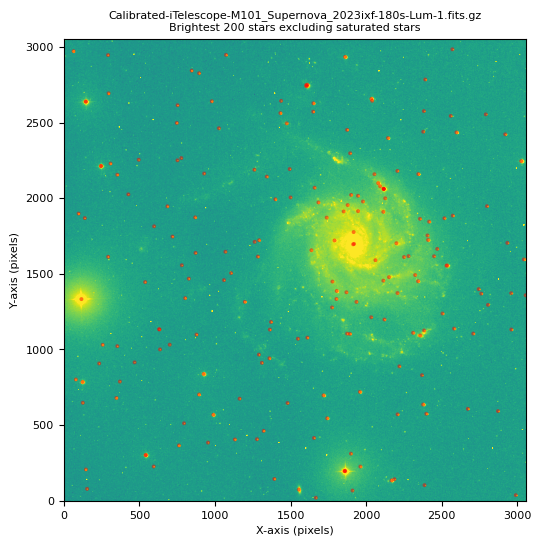

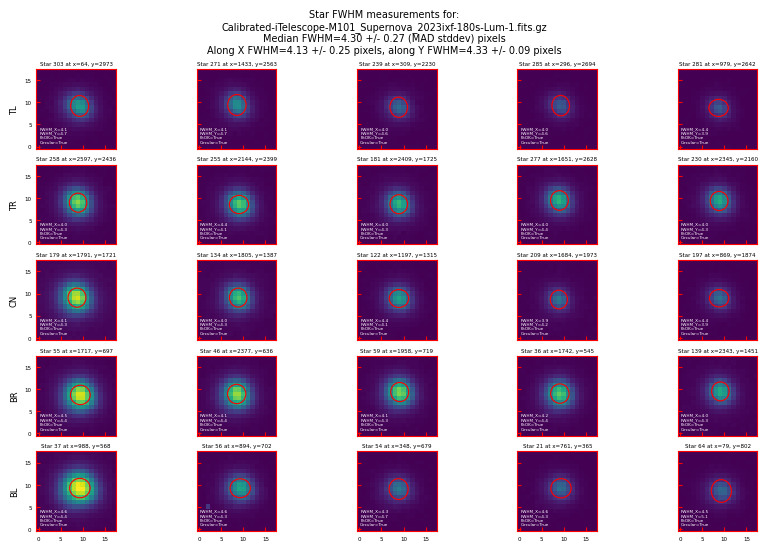

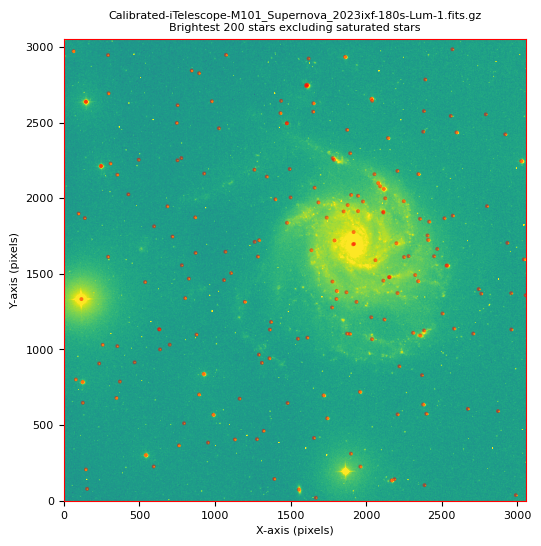

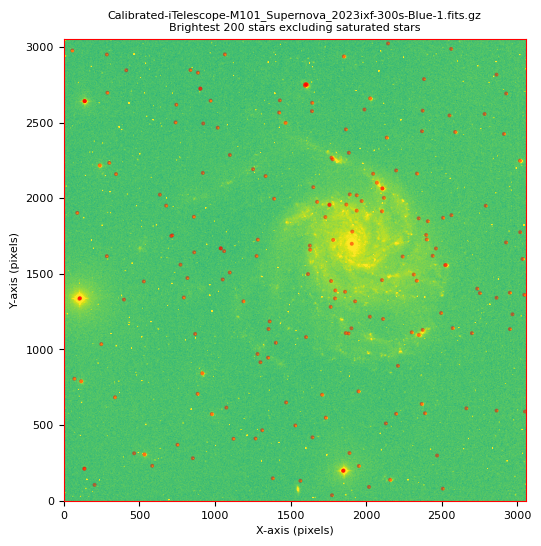

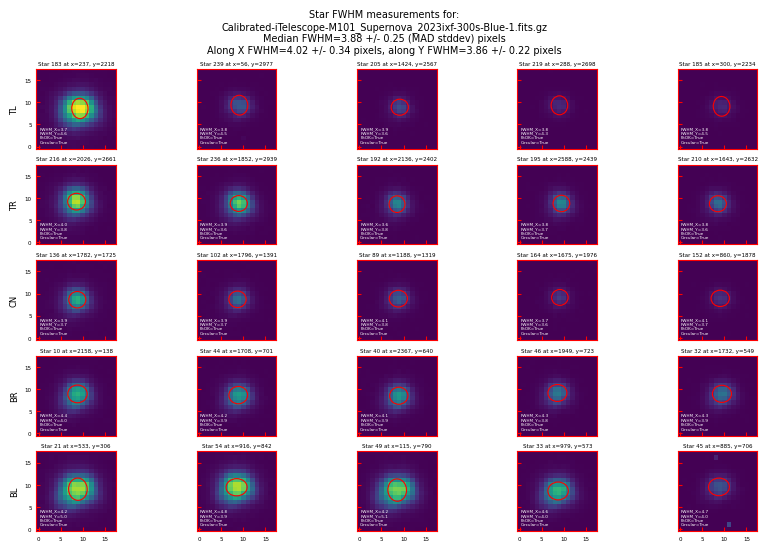

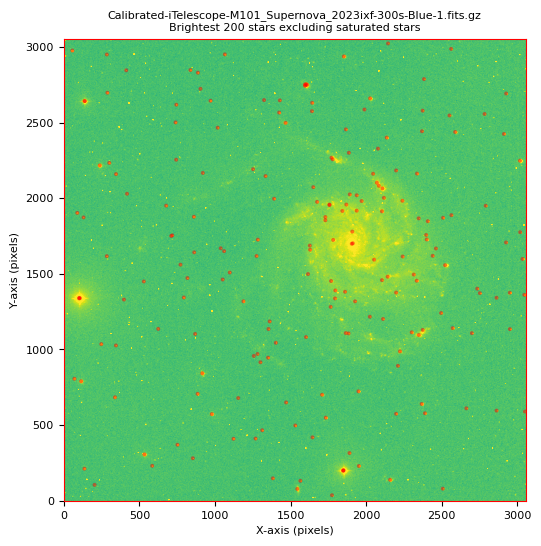

In [12]:
clean_run = True
if clean_run:
    clean_srclists = True
    clean_navfiles = True
else:
    clean_srclists = False
    clean_navfiles = False

# For initial debugging it it best to make sure exceptions terminate the run.
# And all output is sent to the screen
initial_debugging = True
if initial_debugging:
    stop_on_error = True
    quiet = False
    init_filelist = ['Calibrated-iTelescope-M101_Supernova_2023ixf-180s-Lum-1.fits.gz', 
                     'Calibrated-iTelescope-M101_Supernova_2023ixf-300s-Blue-1.fits.gz']
    status = processor.navigate_images(data_dir, include_pattern, exclude_pattern, init_filelist, None, '.fits.gz', 
                                   quality_summary_file, clean_srclists, clean_navfiles, stop_on_error=stop_on_error, quiet=quiet)

else:
    # Once the first few files work, the better default is
    stop_on_error = False
    quiet = True

    status = processor.navigate_images(data_dir, include_pattern, exclude_pattern, None, None, '.fits.gz', 
                                   quality_summary_file, clean_srclists, clean_navfiles, stop_on_error=stop_on_error, quiet=quiet)



In [13]:
# show status table
status.pprint(max_width=200)

                            filename                             find_stars_status find_stars_time astrometry_status astrometry_time
---------------------------------------------------------------- ----------------- --------------- ----------------- ---------------
 Calibrated-iTelescope-M101_Supernova_2023ixf-180s-Lum-1.fits.gz              pass           8.378              pass         142.415
Calibrated-iTelescope-M101_Supernova_2023ixf-300s-Blue-1.fits.gz              pass           8.423              pass          93.932


The processing times for each stage depend on the host processor single CPU speed (single threaded python), but will typically be longer for the astrometry stage as the time depends on the nova.astrometry.net web service. This depends on their CPU oad, but also very strongly on the number of possible locations and scales it needs to consider. `ApAstrometry` tries to provide a number of hints to `Astrometry.net`, the more of which are present the more likely a successful solution in a shorter time.

In particular, if `ApFindStars` can estimate the approximate plate scale of the images, then astrometric solutions are much faster although astrometry is always slower than the source searching. Note that raw and calibrated images from `iTelescope` often have the FITS header keywords needed for approximate plate scale estimation, but they are often stripped out of iTelescope Premium image sets.

In [15]:
# Load and display the quality summary table (NOTE this is a very wide table)
qual_summ_table = Table.read(quality_summary_file, format="ascii.csv")
qual_summ_table.columns   # Dict of table columns (access by column name, index, or slice)
qual_summ_table.colnames  # List of column names
qual_summ_table.meta      # Dict of meta-data
len(qual_summ_table)      # Number of table rows

<TableColumns names=('targ:tel:filter','file','ncols','nrows','filter','median','stddev','num_detected','num_with_photometry','search_nsigma','adups_brightest','adups_median','adups_faintest','num_saturated_in_image','num_saturated_in_photometry','num_fit','circular_psf','fwhm_val_pix','fwhm_err_pix','fwhm_val_arcs','fwhm_err_arcs','num_data_pts')>

['targ:tel:filter',
 'file',
 'ncols',
 'nrows',
 'filter',
 'median',
 'stddev',
 'num_detected',
 'num_with_photometry',
 'search_nsigma',
 'adups_brightest',
 'adups_median',
 'adups_faintest',
 'num_saturated_in_image',
 'num_saturated_in_photometry',
 'num_fit',
 'circular_psf',
 'fwhm_val_pix',
 'fwhm_err_pix',
 'fwhm_val_arcs',
 'fwhm_err_arcs',
 'num_data_pts']

OrderedDict()

12

In [21]:
# Show some data from the quality summary data.
qual_summ_table['file', 'ncols','nrows','filter','median','stddev',
    'num_detected','fwhm_val_pix','fwhm_err_pix','fwhm_val_arcs','fwhm_err_arcs','num_data_pts'].pprint_all()

                               file                               ncols nrows filter   median     stddev  num_detected fwhm_val_pix fwhm_err_pix fwhm_val_arcs fwhm_err_arcs num_data_pts
----------------------------------------------------------------- ----- ----- ------ ---------- --------- ------------ ------------ ------------ ------------- ------------- ------------
 Calibrated-iTelescope-M101_Supernova_2023ixf-300s-Blue-2.fits.gz  3056  3056   Blue 179.874023 21.801167          278     3.465217     0.284413        -999.0        -999.0           50
 Calibrated-iTelescope-M101_Supernova_2023ixf-300s-Blue-3.fits.gz  3056  3056   Blue 183.536133 21.837498          266     3.625976     0.287341        -999.0        -999.0           48
 Calibrated-iTelescope-M101_Supernova_2023ixf-300s-Blue-1.fits.gz  3056  3056   Blue 184.711258 21.853487          243     3.883582     0.247384        -999.0        -999.0           48
Calibrated-iTelescope-M101_Supernova_2023ixf-300s-Green-1.fits.gz  305

The quality summary file provides a general overview of the images that have been processed. (Note it summarizes all quality `YaML` files in the specified directory, not just the ones generated in the latest run of the `navigate_images` function.)

- The file is grouped by Filter, even if the lexical order of the files names is different.
- Comparing different observations using the same filter can provide information that can be later used to exlcude peculiar or bad images
   - The sigma-clipped background level, with detected sources removed, `median` +/- `stddev` (standard deviation) is one way to check
     if a particular image is affected by clouds. For example the Blue filter images have very similar background levels of 180+/-22, 184+/-22, and 185+/-22 ADU.
     The third Green filter image, on the other hand, differs from the others in have a background level of 177+/-22 compared to 233+/-23 and 223+/-23.
   - The number of detected sources should likewise be similar, and again the third Green image differs from the first and second Green images.
- The most important statistic are the measured source full width at half maximum, a measure of the telescope resolution, seeing conditions and tracking stability. Outliers here should like be excluded from image stacking.
   - In this case only the values in pixel units, not arcseconds are valid. That is because the pixel-to-arcsecond conversion used by ApMeasureStars comes
     from plate scale FITS header keywords. The are often missing from  iTelescope Premium datasets.

### Checking the Navigated Images

It is recommended that you check that the WCS headers give reasonable results and are self consistent. I personally prefer to use `SAOImage ds9` for this from the command line, by loading the images, aligning them and then blinking between the images. If the astrometry is good then the same star should be in the same place on the screen in each image, and not move or jump from frame to frame.

```bash
> cd ./NavigatedImages/
> ls
navigated-M101_Supernova_2023ixf-180s-Lum-1.fits   navigated-M101_Supernova_2023ixf-300s-Green-1.fits
navigated-M101_Supernova_2023ixf-180s-Lum-2.fits   navigated-M101_Supernova_2023ixf-300s-Green-2.fits
navigated-M101_Supernova_2023ixf-180s-Lum-3.fits   navigated-M101_Supernova_2023ixf-300s-Green-3.fits
navigated-M101_Supernova_2023ixf-300s-Blue-1.fits  navigated-M101_Supernova_2023ixf-300s-Red-1.fits
navigated-M101_Supernova_2023ixf-300s-Blue-2.fits  navigated-M101_Supernova_2023ixf-300s-Red-2.fits
navigated-M101_Supernova_2023ixf-300s-Blue-3.fits  navigated-M101_Supernova_2023ixf-300s-Red-3.fits
> ds9  -asinh -zoom to fit -cmap viridis -scale mode 99.5 navigated-M101_Supernova_2023ixf-*fits &
```

Then:
- expand the ds9 window to make it larger
- click on the first image (or any image) so that it is outlined in blue
- Mousing over pixels in that image should change the WCS RA and Dec values shown
- Click the menu `Zoom` -> `Align` and the first image and the zoomed-out view in the top right should change orientation
- Cleck `Frame` -> `Single Frame`, then `Zoom` -> `Fit`
- Now to match all the images by RA and Dec, `Frame` -> `Match` -> `Frame` -> `WCS`
- Make sure the default blink interval is 1 second (less than 1 second is too fast) by `Frame` -> `Frame Parameters` -> `Blink Interval`
- Finally, set the images to blink using `Frame` ->  `Blink Frames`


## Image Stacking (Resampling and Mosaicing)

`ApProcessor` can also resample images to a common WCS system, and mosaic multiple images sharing a common WCS together, using `Astromatic` `swarp` under the hood. These operations are more commonly referred to as image stacking in the amateur astronomy community.

As discussed in the `itelescope_premium_the_hard_way.ipynb` notebook there are a number of ways of doing this.

# Versions and Changes

| Version | Date | Description |
|:--------|------|-------------|
| 0.5.2-alpha1 | 2024-04-26 | Created script skeleton. |

In [ ]:
status.pprint(max_width=200)